In [1]:
import pickle
import itertools

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import newton

In [2]:
run_name = "minmax_95_5_prank_3"
with open(f"data/eda_results/eda_human_{run_name}.pkl", "rb") as f:
    results = pickle.load(f)
pf = results["converged_pf_table"][-1]

find curvature p:

In [3]:
# turn max to min
pf = -pf
pf_ideal = pf.min(axis=0)
pf_nadir = pf.max(axis=0)
pf_norm = (pf - pf_ideal) / (pf_nadir - pf_ideal)
pf_norm_cleaned = pf_norm[~np.any((pf_norm == 0) | (pf_norm == 1), axis=1)]

p_list = np.zeros(len(pf_norm_cleaned))
for i, a in enumerate(pf_norm_cleaned):
    def f(x):
        return np.log(np.sum(a**x))
    p = newton(f, 1)
    p_list[i] = p

print(np.mean(p_list))
print(np.median(p_list))

2.55097670177689
2.4413763680071323


In [ ]:
# keep max
pf_ideal = pf.max(axis=0)
pf_nadir = pf.min(axis=0)
pf_norm = (pf - pf_nadir) / (pf_ideal - pf_nadir)
pf_norm_cleaned = pf_norm[~np.any((pf_norm == 0) | (pf_norm == 1), axis=1)]
z_ideal = pf_norm.max(axis=0)
print(z_ideal)

p_list = np.zeros(len(pf_norm_cleaned))
for i, a in enumerate(pf_norm_cleaned):
    def f(x):
        return np.log(np.sum((z_ideal - a)**x))
    # def f(x):
    #     return np.sum((z_ideal - a)**x) - 1
    p = newton(f, 1)
    p_list[i] = p

print(np.mean(p_list))
print(np.median(p_list))

In [3]:
# use loop instead of scipy.optimize.newton
def estimate_p_one_point(a, p0=1.0, tol=1e-5, max_iter=50, eps=1e-12):
    p = float(p0)
    for _ in range(max_iter):
        f_prime = np.log(np.sum(a ** p)) / np.sum((a ** p) * np.log(a))
        
        p_new = p - f_prime
        if not np.isfinite(p_new) or p_new <= 0:
            raise ValueError("p_new is not finite or non-positive")
        if abs(f_prime) <= tol:
            return p_new

        p = p_new
    return p

pf = -pf
pf_ideal = pf.min(axis=0)
pf_nadir = pf.max(axis=0)
pf_norm = (pf - pf_ideal) / (pf_nadir - pf_ideal)
pf_norm_cleaned = pf_norm[~np.any((pf_norm == 0) | (pf_norm == 1), axis=1)]

p_list = np.zeros(len(pf_norm_cleaned))
for i, a in enumerate(pf_norm_cleaned):
    p = estimate_p_one_point(a)
    p_list[i] = p

print(np.mean(p_list))
print(np.median(p_list))

2.5509767017685014
2.441376367990479


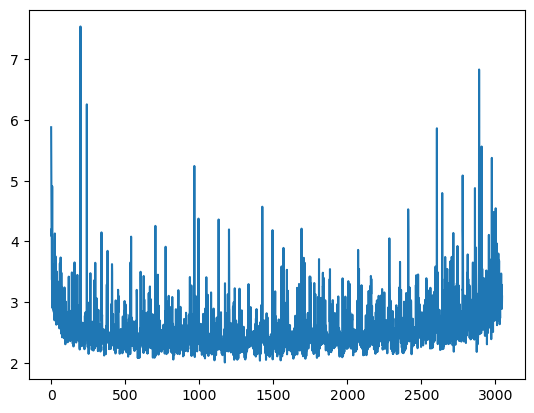

In [4]:
plt.plot(p_list)
plt.show()

In [ ]:
# if need to choose a randomly
rng = np.random.default_rng(20)
a = rng.choice(pf_norm, size=1, axis=0).flatten()
print(a)

compute geodesics:

In [7]:
p = 2.5

# project a point to estimated manifold
def project(a, p):
    return a / (np.sum(a ** p) ** (1/p))

# project pf to estimated manifold
def project_pf(pf, p):
    return pf / (np.sum(pf ** p, axis=1, keepdims=True) ** (1/p))

# compute geodesic distance between two points
def geodesic_distance(a, b, p):
    midpoint = (a + b) / 2
    midpoint_proj = project(midpoint, p)
    d = np.linalg.norm(midpoint_proj - a) + np.linalg.norm(midpoint_proj - b)
    return d

pf_proj = project_pf(pf_norm_cleaned, p)
D = np.zeros((len(pf_proj), len(pf_proj)))
for i, a in enumerate(pf_proj):
    for j, b in enumerate(pf_proj):
        if i == j:
            continue
        
        d = geodesic_distance(a, b, p)
        D[i, j] = d
        D[j, i] = d

np.fill_diagonal(D, np.inf)
diversity = np.min(D, axis=1)

In [10]:
D.shape

(3046, 3046)

test problem (minimization):

In [ ]:
# test pf
theta = np.linspace(0.05, np.pi / 2 - 0.05, 50)
pf = np.column_stack([
    np.cos(theta),
    np.sin(theta)
])
print(pf)

In [ ]:
# normalize test pf
pf_ideal = pf.min(axis=0)
pf_nadir = pf.max(axis=0)
pf_norm = (pf - pf_ideal) / (pf_nadir - pf_ideal)

pf_norm_cleaned = pf_norm[~np.any((pf_norm == 0) | (pf_norm == 1), axis=1)]

In [ ]:
# estimate p for each solution
p_list = np.zeros(len(pf_norm_cleaned))
for i, a in enumerate(pf_norm_cleaned):
    def f(x):
        return np.log(np.sum(a**x))
    p = newton(f, 1)
    p_list[i] = p

print(np.mean(p_list))
print(np.median(p_list))

In [ ]:
plt.plot(p_list)
plt.show()

In [ ]:
# normalizing test pf leads to p not equal to 2
# because normalized pf is not the unit circle anymore
# keep original pf to obtain p close to 2

theta = np.linspace(0.05, np.pi / 2 - 0.05, 50)

pf = np.column_stack([
    np.cos(theta),
    np.sin(theta)
])

p_list = np.zeros(len(pf))

for i, a in enumerate(pf):
    def f(x):
        return np.log(np.sum(a**x))
    p = newton(f, 1)
    p_list[i] = p

print(np.mean(p_list))
print(np.median(p_list))